In [1]:
from pathlib import Path
import sys
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Make src importable
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Dataset paths
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IDRiD"
    / "B. Disease Grading"
)

TRAIN_IMAGE_DIR = (
    DATA_DIR
    / "1. Original Images"
    / "a. Training Set"
)

GROUNDTRUTH_DIR = (
    DATA_DIR
    / "2. Groundtruths"
)

TRAIN_LABEL_PATH = (
    GROUNDTRUTH_DIR
    / "a. IDRiD_Disease Grading_Training Labels.csv"
)

print("Project root:", PROJECT_ROOT)
print("Training images:", TRAIN_IMAGE_DIR)
print("Labels:", TRAIN_LABEL_PATH)

Project root: /home/deepak/projects/aiml_biodata
Training images: /home/deepak/projects/aiml_biodata/data/raw/IDRiD/B. Disease Grading/1. Original Images/a. Training Set
Labels: /home/deepak/projects/aiml_biodata/data/raw/IDRiD/B. Disease Grading/2. Groundtruths/a. IDRiD_Disease Grading_Training Labels.csv


In [3]:
from src.features.feature_extraction import extract_all_features

In [5]:
GROUNDTRUTH_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IDRiD"
    / "B. Disease Grading"
    / "2. Groundtruths"
)

TRAIN_LABEL_PATH = (
    GROUNDTRUTH_DIR
    / "a. IDRiD_Disease Grading_Training Labels.csv"
)

In [21]:
labels_df = pd.read_csv(TRAIN_LABEL_PATH)

labels = labels_df[
    ["Image name", "Retinopathy grade"]
].copy()

labels["image_id"] = labels["Image name"].astype(str)

labels = labels[
    ["image_id", "Retinopathy grade"]
]

display(labels.head())
print("Shape:", labels.shape)

,image_id,Retinopathy grade
0,IDRiD_001,3
1,IDRiD_002,3
2,IDRiD_003,2
3,IDRiD_004,3
4,IDRiD_005,4


Shape: (413, 2)


In [22]:
print(labels_df["Unnamed: 11"].value_counts(dropna=False))

Unnamed: 11
NaN    412
         1
Name: count, dtype: int64


In [23]:
image_paths = sorted(TRAIN_IMAGE_DIR.glob("*.jpg"))

print("Number of training images:", len(image_paths))

Number of training images: 413


In [24]:
rows = []

for i, image_path in enumerate(image_paths, start=1):

    print(f"Processing {i}/{len(image_paths)}: {image_path.name}")

    features = extract_all_features(image_path)

    # Keep track of which image produced these features
    features["image_id"] = image_path.stem

    rows.append(features)

Processing 1/413: IDRiD_001.jpg
Processing 2/413: IDRiD_002.jpg
Processing 3/413: IDRiD_003.jpg
Processing 4/413: IDRiD_004.jpg
Processing 5/413: IDRiD_005.jpg
Processing 6/413: IDRiD_006.jpg
Processing 7/413: IDRiD_007.jpg
Processing 8/413: IDRiD_008.jpg
Processing 9/413: IDRiD_009.jpg
Processing 10/413: IDRiD_010.jpg
Processing 11/413: IDRiD_011.jpg
Processing 12/413: IDRiD_012.jpg
Processing 13/413: IDRiD_013.jpg
Processing 14/413: IDRiD_014.jpg
Processing 15/413: IDRiD_015.jpg
Processing 16/413: IDRiD_016.jpg
Processing 17/413: IDRiD_017.jpg
Processing 18/413: IDRiD_018.jpg
Processing 19/413: IDRiD_019.jpg
Processing 20/413: IDRiD_020.jpg
Processing 21/413: IDRiD_021.jpg
Processing 22/413: IDRiD_022.jpg
Processing 23/413: IDRiD_023.jpg
Processing 24/413: IDRiD_024.jpg
Processing 25/413: IDRiD_025.jpg
Processing 26/413: IDRiD_026.jpg
Processing 27/413: IDRiD_027.jpg
Processing 28/413: IDRiD_028.jpg
Processing 29/413: IDRiD_029.jpg
Processing 30/413: IDRiD_030.jpg
Processing 31/413: 

In [27]:
dataset_df = features_df.merge(
    labels,
    on="image_id",
    how="inner"
)

print("Final dataset shape:", dataset_df.shape)
display(dataset_df.head())

Final dataset shape: (413, 29)


,mean_r,mean_g,mean_b,std_r,std_g,std_b,median_r,median_g,median_b,glcm_contrast,...,mean_aspect_ratio,mean_circularity,mean_solidity,vessel_area,vessel_density,num_vessel_components,mean_vessel_component_area,std_vessel_component_area,image_id,Retinopathy grade
0,171.874544,84.761409,10.862817,28.550963,20.078228,4.606147,170.0,82.0,10.0,0.127163,...,0.646290,0.552371,0.869051,19728,0.108514,197,100.142132,453.807323,IDRiD_001,3
1,169.477023,83.419822,11.629892,26.866515,17.173646,4.661440,173.0,83.0,11.0,0.126919,...,0.708822,0.390917,0.734459,18137,0.099862,200,90.685000,555.921987,IDRiD_002,3
2,161.807197,47.938058,1.404106,30.105872,11.566063,1.461934,166.0,49.0,1.0,0.081374,...,0.633333,0.544873,0.861186,24874,0.137199,310,80.238710,690.090018,IDRiD_003,2
3,141.874462,76.912938,22.279137,35.989964,26.303989,8.630401,139.0,71.0,20.0,0.103099,...,0.688230,0.522832,0.883993,23463,0.129246,199,117.904523,442.307263,IDRiD_004,3
4,159.712094,85.984632,44.247228,23.333006,17.442928,12.035322,161.0,85.0,44.0,0.095401,...,0.579832,0.319334,0.726712,31011,0.170813,347,89.368876,363.534620,IDRiD_005,4


In [29]:
print("Shape:", dataset_df.shape)

print("\nMissing values:")
print(dataset_df.isnull().sum())

print("\nDuplicate rows:", dataset_df.duplicated().sum())

print("\nDuplicate image IDs:", dataset_df["image_id"].duplicated().sum())

Shape: (413, 29)

Missing values:
mean_r                        0
mean_g                        0
mean_b                        0
std_r                         0
std_g                         0
std_b                         0
median_r                      0
median_g                      0
median_b                      0
glcm_contrast                 0
glcm_dissimilarity            0
glcm_homogeneity              0
glcm_energy                   0
candidate_area                0
candidate_area_ratio          0
num_regions                   0
largest_region_area           0
mean_region_area              0
std_region_area               0
mean_aspect_ratio             0
mean_circularity              0
mean_solidity                 0
vessel_area                   0
vessel_density                0
num_vessel_components         0
mean_vessel_component_area    0
std_vessel_component_area     0
image_id                      0
Retinopathy grade             0
dtype: int64

Duplicate rows: 0

Dupli

In [30]:
feature_columns = [
    col for col in dataset_df.columns
    if col not in ["image_id", "Retinopathy grade"]
]

X = dataset_df[feature_columns]
y = dataset_df["Retinopathy grade"]

print("X:", X.shape)
print("y:", y.shape)

X: (413, 27)
y: (413,)


In [31]:
feature_stats = X.describe().T

display(feature_stats)

,count,mean,std,min,25%,50%,75%,max
mean_r,413.0,158.658904,27.468988,64.182889,143.020940,161.153546,176.511775,219.942613
mean_g,413.0,77.177169,18.826486,24.919775,65.967527,78.373384,90.105990,124.685655
mean_b,413.0,25.367476,18.878096,0.026808,9.980504,20.971266,38.941544,94.129881
std_r,413.0,27.880003,4.905641,15.958862,24.785668,27.318067,29.910788,54.455172
std_g,413.0,20.450884,5.452353,6.327320,17.112514,20.413760,23.774812,52.714907
std_b,413.0,9.676240,6.493382,0.241980,4.284793,7.879478,14.233336,33.366412
median_r,413.0,157.585956,28.310012,57.000000,141.000000,160.000000,176.000000,226.000000
median_g,413.0,74.430993,19.196688,21.000000,62.000000,76.000000,87.000000,126.000000
median_b,413.0,23.590799,17.948270,0.000000,9.000000,19.000000,36.000000,92.000000
glcm_contrast,413.0,0.126801,0.030646,0.056163,0.105316,0.120903,0.145227,0.233412


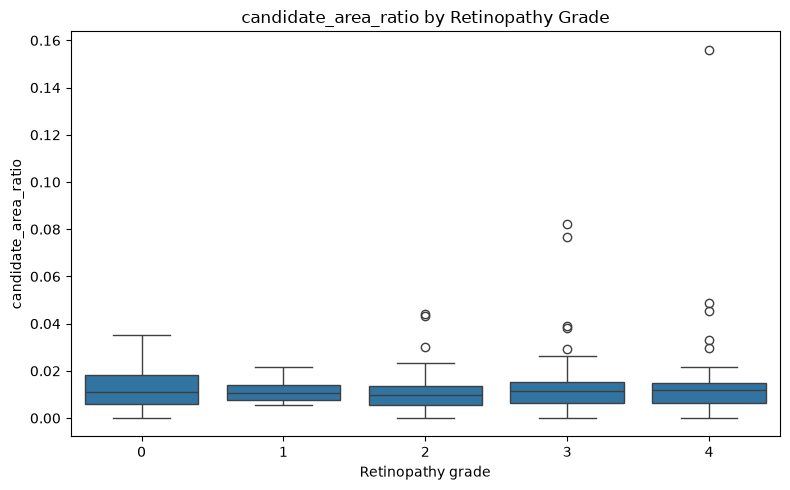

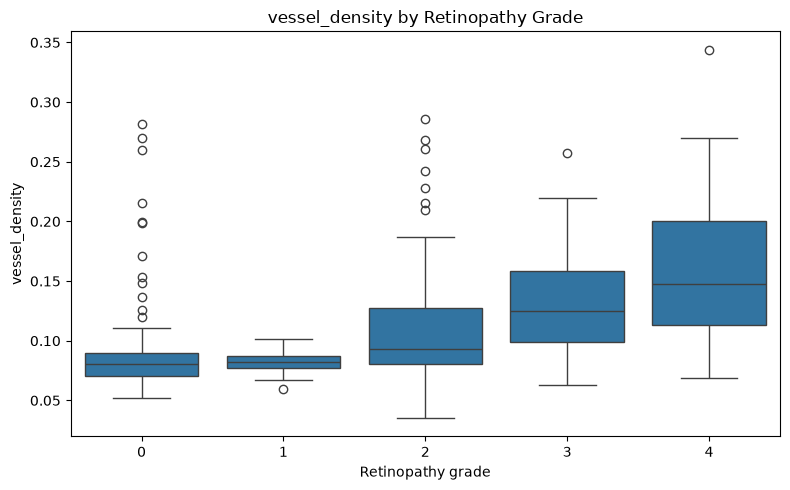

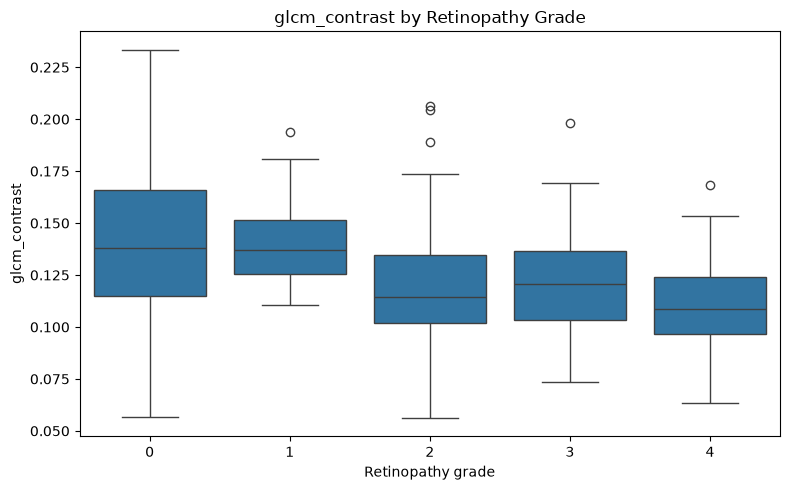

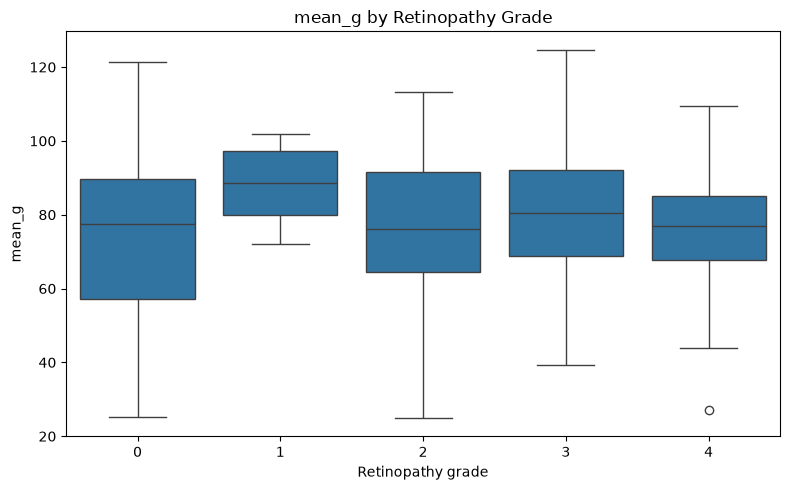

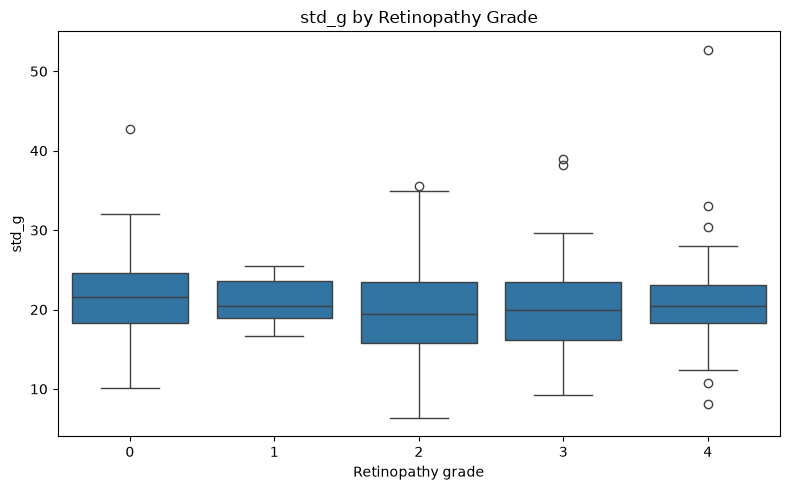

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [
    "candidate_area_ratio",
    "vessel_density",
    "glcm_contrast",
    "mean_g",
    "std_g"
]

for feature in features_to_plot:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=dataset_df,
        x="Retinopathy grade",
        y=feature
    )

    plt.title(f"{feature} by Retinopathy Grade")
    plt.tight_layout()
    plt.show()

In [41]:
from pathlib import Path

OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

output_path = OUTPUT_DIR / "idrid_feature_matrix.csv"

dataset_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /home/deepak/projects/aiml_biodata/data/processed/idrid_feature_matrix.csv
